In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]

store = counts.with_name("data.zarr")
reader = scarf.CrH5Reader(str(counts))

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

In [2]:
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
scarf.CrToZarr(
    reader,
    zarr_loc=str(store),
).dump()

Writing counts: 2 / 2 complete

In [4]:
ds = scarf.DataStore(
    str(store),
    nthreads=4,
)

Computing RNA initialization statistics: 1 / 1 complete

In [5]:
print(f"Active cells: {int(ds.cells.fetch_all('I').sum())} / {ds.cells.N}")
ds.cells.to_pandas_dataframe(
    columns=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
).describe().loc[["min", "50%", "max"]]

Active cells: 5025 / 5025


,RNA_nCounts,RNA_nFeatures,RNA_percentMito
min,502.0,38.0,0.188857
50%,7803.0,2171.0,8.610924
max,46913.0,6160.0,96.791444


In [6]:
n_before = int(ds.cells.fetch_all("I").sum())
artifacts = ds.pipeline.run()
n_after = int(ds.cells.fetch_all("I").sum())
print(f"Active cells before pipeline: {n_before}")
print(f"Active cells after pipeline: {n_after}")

selected = next(
    key
    for key, ref in artifacts.items()
    if key != "selected_clusters" and ref == artifacts["selected_clusters"]
)
print(f"RNA_clusters selected from: {selected}")

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

...

Training UMAP: 300 / 300 complete

Writing simulated doublets: 1 / 1 complete

Computing RNA initialization statistics: 1 / 1 complete

Finding markers: 2 / 2 complete

Active cells before pipeline: 5025
Active cells after pipeline: 4618
RNA_clusters selected from: leiden_0.5


In [7]:
ds.cells.to_pandas_dataframe(
    columns=["RNA_clusters"],
    key="I",
)["RNA_clusters"].value_counts().sort_index()

RNA_clusters
1      893
2      271
3     1447
4      356
5      506
6      240
7      273
8      503
9       31
10      75
11      23
Name: count, dtype: int64

In [8]:
ds.cells.to_pandas_dataframe(
    columns=["RNA_leiden_0.5"],
    key="I",
)["RNA_leiden_0.5"].value_counts().sort_index()

RNA_leiden_0.5
1      893
2      271
3     1447
4      356
5      506
6      240
7      273
8      503
9       31
10      75
11      23
Name: count, dtype: int64

In [9]:
sorted(artifacts)

['ann_index',
 'cell_cycle',
 'cell_selection',
 'connectivity_map',
 'doublets',
 'embedding_initialization',
 'highly_variable_features',
 'leiden_0.5',
 'leiden_0.75',
 'leiden_1.0',
 'leiden_1.25',
 'markers',
 'neighbors',
 'normalized',
 'paris',
 'pca',
 'selected_clusters',
 'umap']

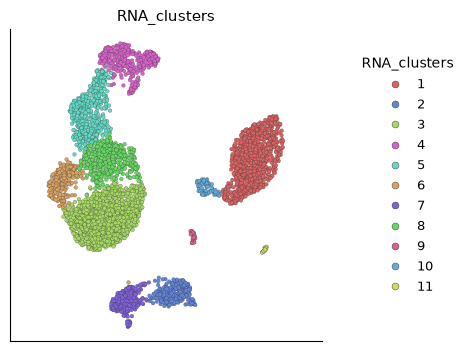

In [10]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_clusters",
)

In [11]:
(
    ds.cells.to_pandas_dataframe(
        columns=["RNA_clusters", "RNA_nCounts"],
        key="I",
    )
    .groupby("RNA_clusters")["RNA_nCounts"]
    .agg(n_cells="size", median_nCounts="median")
    .sort_values("median_nCounts")
)

,n_cells,median_nCounts
RNA_clusters,,
9,31,1151.0
6,240,2111.5
7,273,6250.0
4,356,6275.5
5,506,7586.0
3,1447,7813.0
2,271,8683.0
8,503,8832.0
1,893,11247.0


Aggregating marker values per group: 1 / 1 complete

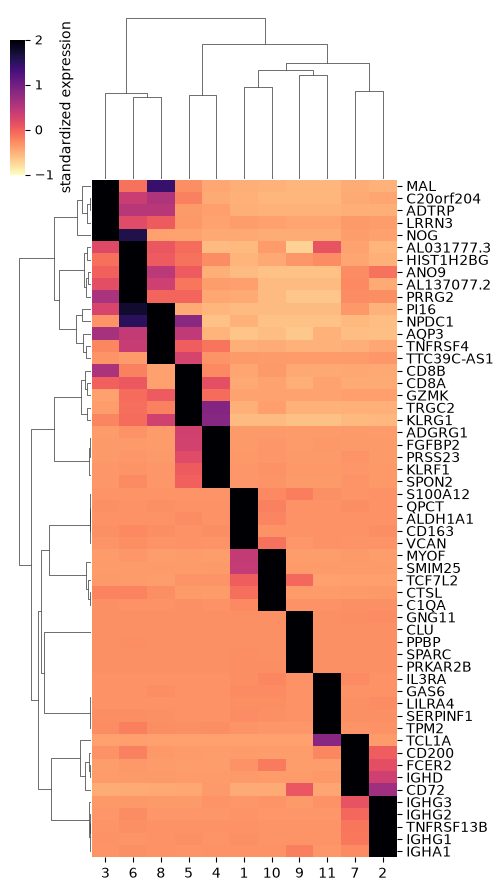

In [12]:
ds.plots.marker_heatmap(
    marker=artifacts["markers"],
    group_key="RNA_clusters",
    topn=5,
    figsize=(5, 9),
)

In [13]:
cluster_id = (
    ds.cells.to_pandas_dataframe(columns=["RNA_clusters"], key="I")["RNA_clusters"]
    .value_counts()
    .index[0]
)
print(f"Markers for cluster {cluster_id}")
ds.get_markers(
    marker=artifacts["markers"],
    group_key="RNA_clusters",
    group_id=cluster_id,
).head(10)

Markers for cluster 3


,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,3,LRRN3,12793,0.72325,0.12685,0.00592,0.54112,0.03154,21.41749,0.000000e+00,0.75758,0.000000e+00
1,3,NOG,27951,0.59662,0.04533,0.00398,0.26399,0.01072,11.39930,2.556512e-170,0.62654,6.213065e-168
2,3,ADTRP,10307,0.56187,0.03784,0.00333,0.21562,0.02050,11.35892,7.107502e-113,0.59819,9.650665e-111
3,3,MAL,4116,0.52330,0.17990,0.02417,0.66551,0.11447,7.44282,0.000000e+00,0.78571,0.000000e+00
4,3,TCEA3,487,0.51850,0.03071,0.00364,0.20871,0.02397,8.42923,3.875020e-101,0.59296,4.192272e-99
5,3,FHIT,6081,0.48789,0.13037,0.01530,0.57913,0.08704,8.51996,6.333931e-303,0.75570,3.426248e-300
6,3,CMTM8,5662,0.47786,0.04427,0.00807,0.28818,0.06055,5.48460,5.272531e-104,0.61663,6.097592e-102
7,3,MAN1C1,536,0.47509,0.04912,0.00922,0.31790,0.06875,5.32900,1.228253e-115,0.62888,1.767947e-113
8,3,LEF1,7964,0.47338,0.22644,0.03187,0.78023,0.13277,7.10572,0.000000e+00,0.83564,0.000000e+00
9,3,CHRM3-AS2,3027,0.46975,0.06475,0.00964,0.37042,0.04951,6.71767,6.396571e-179,0.66230,1.650217e-176
